# 02 Preprocessing

Run the reusable preprocessing pipeline and inspect the cleaned outputs.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import json
import pandas as pd

from src.preprocess import run_preprocessing
from src.data_utils import build_paths

metadata = run_preprocessing()
metadata

Skipping annotator_1_data.csv: annotator_1_data.csv is missing required columns: include, sentiment_label
Skipping annotator_2_data.csv: annotator_2_data.csv is missing required columns: include, sentiment_label
Skipping annotator_3_data.csv: annotator_3_data.csv is missing required columns: include, sentiment_label
Skipping annotator_4_data.csv: annotator_4_data.csv is missing required columns: include, sentiment_label
Skipping annotator_5_data.csv: annotator_5_data.csv is missing required columns: include, sentiment_label
Skipping annotator_6_data.csv: annotator_6_data.csv is missing required columns: include, sentiment_label
Skipped 6 raw files without the required annotation schema.


{'random_seed': 42,
 'raw_rows': 1913,
 'rows_after_filtering': 1487,
 'excluded_rows': 426,
 'duplicate_rows_dropped': 42,
 'invalid_label_rows': 51,
 'missing_text_rows': 21,
 'split_sizes': {'train': 1040, 'val': 223, 'test': 224},
 'label_distribution': {'negative': 1005, 'neutral': 341, 'positive': 141},
 'emoji_rows': 359,
 'emoji_token_count': 1091,
 'raw_files': ['Copy of Facebook_Comment_Annotation - Perpetual.csv',
  'Facebook_comments - Lutha.csv',
  'Facebook_comments - phiti.csv',
  'Facebook_comments - rahe.csv',
  'Facebook_comments - viwo.csv',
  'facebook-comment-annotation2 - Exposition.csv',
  'facebook-comment-annotation2 - Fitina.csv',
  'facebook-comment-annotation2 - Luthando.csv',
  'facebook-comment-annotation2 - Perpetual.csv',
  'facebook-comment-annotation2 - Rahema.csv',
  'sentiment - Alfred.csv',
  'sentiment - Fitina.csv',
  'sentiment - Rahema.csv',
  'sentiment - Thando.csv',
  'sentiment - Viwongo.csv',
  'sentiment - perpetual.csv',
  'sentiment spre

In [2]:
paths = build_paths()
cleaned = pd.read_csv(paths.interim_dir / 'cleaned_comments.csv')
cleaned[['text', 'cleaned_text', 'label']].head(20)

,text,cleaned_text,label
0,Zamphamvu kwambiri,zamphamvu kwambiri,positive
1,"Learning by doing approach, that's wonderful 🔥 🔥.","learning by doing approach , that ' s wonderfu...",positive
2,Code kampani ya maheu ija ili kut inu a mcp..,code kampani ya maheu ija ili kut inu a mcp..,neutral
3,Something that the presidents failed to do!🔥,something that the presidents failed to do!🔥 e...,positive
4,Kma andale akanakhar amaganizaso ngat big man ...,kma andale akanakhar amaganizaso ngat big man ...,neutral
5,"Zikatero boma la DPP limukorekole, ma mafia am...","zikatero boma la dpp limukorekole , ma mafia a...",negative
6,Uyu mpaseni u president 🥳,uyu mpaseni u president 🥳 emoji_partying_face,positive
7,Pomwe ma politicians amakhala busy kudya mison...,pomwe ma politicians amakhala busy kudya mison...,positive
8,"Dear God, as far as Malawi is concerned. A Nap...","dear god , as far as malawi is concerned. a na...",positive
9,"Zomwe dzombe sangapange,boma la Malawi silinga...","zomwe dzombe sangapange , boma la malawi silin...",positive


In [3]:
cleaned.head(10)

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file,sentiment_label_normalized,include_normalized,...,token_count_whitespace,is_short_comment,is_duplicate_text,exclude_reason,label,emoji_aliases,emoji_count,cleaned_text,tokens,token_count_cleaned
0,332.0,Zamphamvu kwambiri,Economy,positive,Medium,Yes,praise,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,2,False,False,NaN,positive,NaN,0,zamphamvu kwambiri,"['zamphamvu', 'kwambiri']",2
1,334.0,"Learning by doing approach, that's wonderful 🔥 🔥.",Economy,positive,High,Yes,teaching method,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,8,False,False,NaN,positive,emoji_fire emoji_fire,2,"learning by doing approach , that ' s wonderfu...","['learning', 'by', 'doing', 'approach', ',', '...",13
2,335.0,Code kampani ya maheu ija ili kut inu a mcp..,Economy,Neutral,medium,Yes,company,Copy of Facebook_Comment_Annotation - Perpetua...,neutral,yes,...,10,False,False,NaN,neutral,NaN,0,code kampani ya maheu ija ili kut inu a mcp..,"['code', 'kampani', 'ya', 'maheu', 'ija', 'ili...",10
3,336.0,Something that the presidents failed to do!🔥,Economy,positive,High,Yes,leadership comparison,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,7,False,False,NaN,positive,emoji_fire,1,something that the presidents failed to do!🔥 e...,"['something', 'that', 'the', 'presidents', 'fa...",8
4,337.0,Kma andale akanakhar amaganizaso ngat big man ...,Economy,Neutral,Medium,Yes,governance comment,Copy of Facebook_Comment_Annotation - Perpetua...,neutral,yes,...,25,False,False,NaN,neutral,emoji_folded_hands,1,kma andale akanakhar amaganizaso ngat big man ...,"['kma', 'andale', 'akanakhar', 'amaganizaso', ...",27
5,339.0,"Zikatero boma la DPP limukorekole, ma mafia am...",Economy,negative,medium,Yes,criticism of government,Copy of Facebook_Comment_Annotation - Perpetua...,negative,yes,...,21,False,False,NaN,negative,NaN,0,"zikatero boma la dpp limukorekole , ma mafia a...","['zikatero', 'boma', 'la', 'dpp', 'limukorekol...",25
6,340.0,Uyu mpaseni u president 🥳,Economy,positive,High,Yes,praise,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,5,False,False,NaN,positive,emoji_partying_face,1,uyu mpaseni u president 🥳 emoji_partying_face,"['uyu', 'mpaseni', 'u', 'president', '🥳', 'emo...",6
7,341.0,Pomwe ma politicians amakhala busy kudya mison...,Economy,positive,Medium,Yes,NaN,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,21,False,False,NaN,positive,NaN,0,pomwe ma politicians amakhala busy kudya mison...,"['pomwe', 'ma', 'politicians', 'amakhala', 'bu...",21
8,342.0,"Dear God, as far as Malawi is concerned. A Nap...",Economy,positive,Medium,Yes,leadership,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,12,False,False,NaN,positive,NaN,0,"dear god , as far as malawi is concerned. a na...","['dear', 'god', ',', 'as', 'far', 'as', 'malaw...",13
9,344.0,"Zomwe dzombe sangapange,boma la Malawi silinga...",Economy,positive,High,Yes,comparison praise,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,38,False,False,NaN,positive,NaN,0,"zomwe dzombe sangapange , boma la malawi silin...","['zomwe', 'dzombe', 'sangapange', ',', 'boma',...",47


<Axes: xlabel='sentiment_label_normalized'>

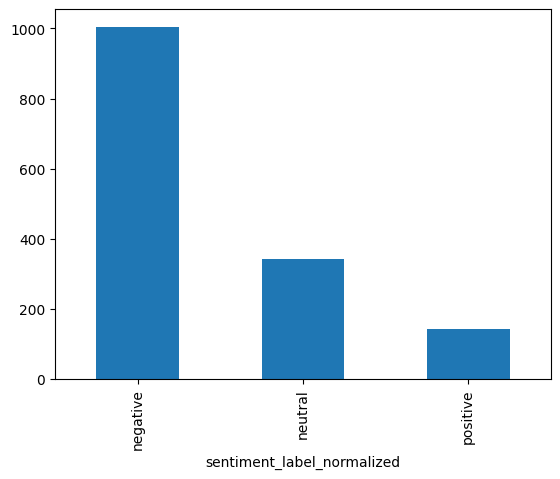

In [4]:
cleaned["sentiment_label_normalized"].value_counts().plot(kind='bar')

In [5]:
cleaned.sample(min(10, len(cleaned)), random_state=42)

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file,sentiment_label_normalized,include_normalized,...,token_count_whitespace,is_short_comment,is_duplicate_text,exclude_reason,label,emoji_aliases,emoji_count,cleaned_text,tokens,token_count_cleaned
1317,779.0,The police will be the one and are the ones pa...,economy,negative,medium,yes,NaN,sentiment spreadsheet - thando.csv,negative,yes,...,12,False,False,NaN,negative,NaN,0,the police will be the one and are the ones pa...,"['the', 'police', 'will', 'be', 'the', 'one', ...",12
1455,460.0,Mwayiwala kuti ndi business munthu amagula m'm...,economy,negative,high,yes,NaN,sentiment spreadsheet - viwongo.csv,negative,yes,...,8,False,False,NaN,negative,NaN,0,mwayiwala kuti ndi business munthu amagula m '...,"['mwayiwala', 'kuti', 'ndi', 'business', 'munt...",10
439,56.0,Ndalama ikuchita kuwopsa mmaso ndiye kutika Mt...,Economy,Negative,High,Yes,sarcasm,Facebook_comments - phiti.csv,negative,yes,...,11,False,False,NaN,negative,emoji_face_with_tears_of_joy emoji_face_with_t...,6,ndalama ikuchita kuwopsa mmaso ndiye kutika mt...,"['ndalama', 'ikuchita', 'kuwopsa', 'mmaso', 'n...",18
560,119.0,Koma abwilibwisi inu zikuyenda mutumo?,economy,Negative,High,yes,NaN,sentiment - Fitina.csv,negative,yes,...,5,False,False,NaN,negative,NaN,0,koma abwilibwisi inu zikuyenda mutumo?,"['koma', 'abwilibwisi', 'inu', 'zikuyenda', 'm...",5
433,50.0,Aganiza bwino,Economy,Positive,High,Yes,NaN,Facebook_comments - phiti.csv,positive,yes,...,2,False,False,NaN,positive,NaN,0,aganiza bwino,"['aganiza', 'bwino']",2
1163,50.0,Whenever the gas ⛽️ is available people do not...,economy,neutral,medium,yes,NaN,sentiment spreadsheet - rahema.csv,neutral,yes,...,55,False,False,NaN,neutral,emoji_fuel_pump emoji_fuel_pump,2,whenever the gas ⛽️ is available people do not...,"['whenever', 'the', 'gas', '⛽️', 'is', 'availa...",57
49,416.0,Interested for that awesome 👏,Economy,Positive,Medium,Yes,NaN,Copy of Facebook_Comment_Annotation - Perpetua...,positive,yes,...,5,False,False,NaN,positive,emoji_clapping_hands,1,interested for that awesome 👏 emoji_clapping_h...,"['interested', 'for', 'that', 'awesome', '👏', ...",6
1454,459.0,Kungowonjezera osusa nawo koma katangare ndi n...,economy,negative,high,yes,NaN,sentiment spreadsheet - viwongo.csv,negative,yes,...,8,False,False,NaN,negative,NaN,0,kungowonjezera osusa nawo koma katangare ndi n...,"['kungowonjezera', 'osusa', 'nawo', 'koma', 'k...",8
482,22.0,Dennis Burton exactly,economy,Positive,High,yes,NaN,Facebook_comments - rahe.csv,positive,yes,...,3,False,False,NaN,positive,NaN,0,dennis burton exactly,"['dennis', 'burton', 'exactly']",3
901,223.0,"Aaaaaaa apolice ake amaluziwa mukunamatu,",economy,negative,high,yes,NaN,sentiment spreadsheet - fitina.csv,negative,yes,...,5,False,False,NaN,negative,NaN,0,"aaaaaaa apolice ake amaluziwa mukunamatu ,","['aaaaaaa', 'apolice', 'ake', 'amaluziwa', 'mu...",6


In [6]:
train = pd.read_csv(paths.processed_dir / 'train.csv')
val = pd.read_csv(paths.processed_dir / 'val.csv')
test = pd.read_csv(paths.processed_dir / 'test.csv')
len(train), len(val), len(test)

(1040, 223, 224)

<Axes: xlabel='sentiment_label_normalized'>

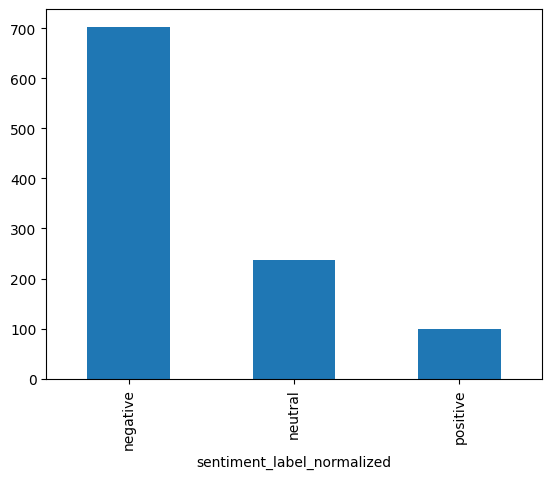

In [7]:
train['sentiment_label_normalized'].value_counts().plot(kind='bar')

<Axes: xlabel='sentiment_label_normalized'>

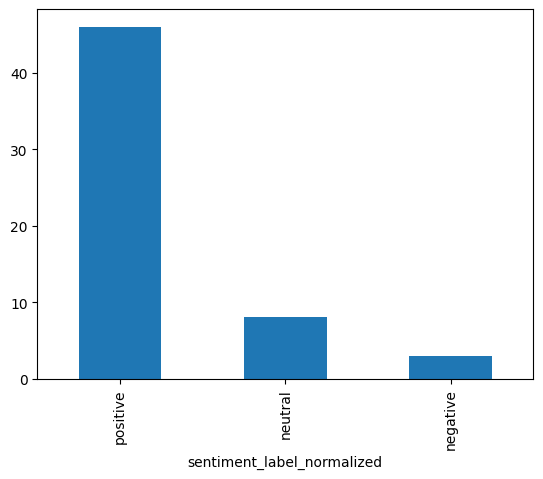

In [14]:
val['sentiment_label_normalized'].value_counts().plot(kind='bar')